# 09_estacionariedad

Proyecto ARIMA / ARIMAX
Modelación epidemiológica con variables meteorológicas.

# Inicio del análisis  

En la construcción de un modelo de pronóstico basado en ARIMA para un sistema de alertas tempranas del Dengue, el **análisis de estacionariedad** es una etapa central, porque estos modelos requieren que la serie temporal sea **estacionaria en media y varianza**.

A continuación te presento **todo el proceso metodológico y computacional** que puedes aplicar a tu dataset semanal de casos de dengue.

---



# 1. Preparación de la serie temporal

Primero se debe garantizar que la serie esté **ordenada por fecha y con índice temporal**.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
# Ubicación para guardar datos consolidados
ubicacion_datos_consolidados_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados"
ubicacion_datos_consolidados_marco = ""
# Ubicación para guardar las imágenes
ubicacion_imagenes_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Gráficos\Estacionariedad"
ubicacion_imagenes_marco = ""

In [23]:
path_janis_datos_procesados = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados\datos_procesados.xlsx"
path_marco = ""

# OJO: la bd procesados contiene tantos los datos originales como los procesados, por lo que se debe tener cuidado al cargarla para no cargar ambos

datos_procesados= pd.read_excel(path_janis_datos_procesados)
# hacer que fecha sea el indice y sea de tipo datetime

datos_procesados['fecha'] = pd.to_datetime(datos_procesados['fecha']) # convertir en tipo datetime
datos_procesados.set_index('fecha', inplace=True)  # hacer que fecha sea el indice



# 2. Inspección visual de la serie

La inspección gráfica permite identificar:

* tendencia
* estacionalidad
* cambios de varianza
* posibles outliers

Usamos Matplotlib.



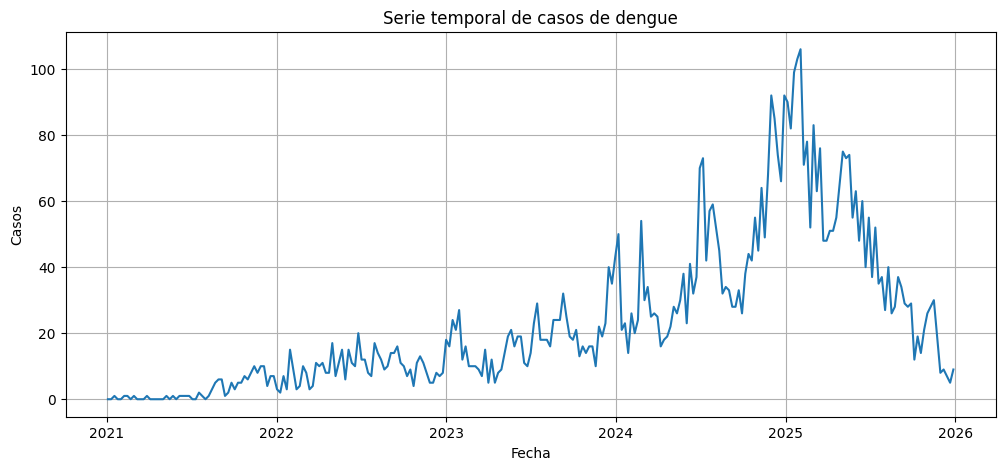

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(datos_procesados.index, datos_procesados['casos_dengue'], linestyle='-')

plt.title('Serie temporal de casos de dengue')
plt.xlabel('Fecha')
plt.ylabel('Casos')
plt.grid(True)
plt.show()



### Interpretación

En tu gráfico previo se observan:

* **tendencia creciente**
* **incremento en la variabilidad**
* **picos epidémicos**

Esto sugiere **no estacionariedad**.

---



# 3. Media y varianza móviles

Una forma simple de evaluar estacionariedad es comparar:

* media móvil
* desviación estándar móvil



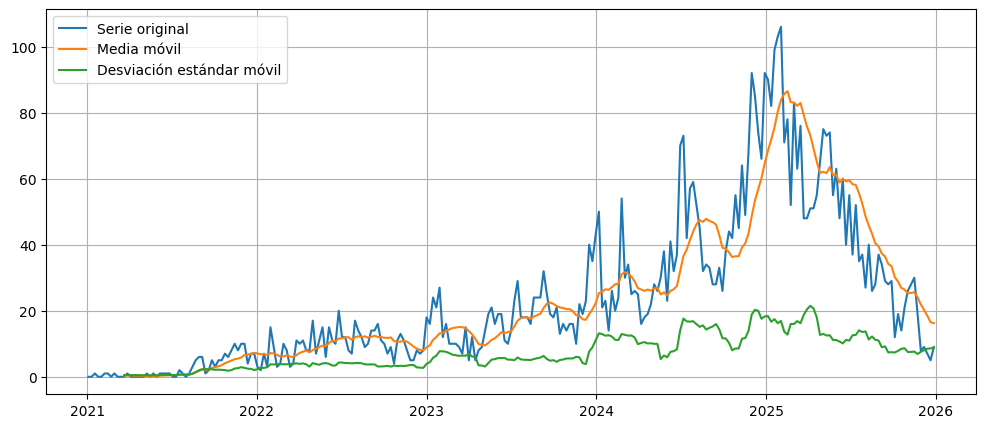

In [33]:
media_movil = datos_procesados['casos_dengue'].rolling(window=12).mean()
std_movil = datos_procesados['casos_dengue'].rolling(window=12).std()

plt.figure(figsize=(12,5))

plt.plot(datos_procesados.index, datos_procesados['casos_dengue'], label='Serie original')
plt.plot(media_movil, label='Media móvil')
plt.plot(std_movil, label='Desviación estándar móvil')

plt.savefig(ubicacion_imagenes_janis + r'\1.serie_casos_dengue_estacionariedad.png', dpi=300)
plt.legend()
plt.grid(True)

plt.show()


```

### Interpretación

Si la serie fuera estacionaria:

* la media sería aproximadamente constante
* la varianza sería aproximadamente constante.

---



# 4. Test estadístico de estacionariedad

Se usa el test de **Augmented Dickey-Fuller test**.

Hipótesis:

$$
H_0 : \text{la serie tiene raíz unitaria (no estacionaria)}
$$

$$
H_1 : \text{la serie es estacionaria}
$$



## Prueba AD Fuller para los datos originales

In [26]:
from statsmodels.tsa.stattools import adfuller

# --- Aplicar ADF ---
resultado = adfuller(datos_procesados["casos_dengue"])

# --- Mostrar resultados ---
print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])
print("Número de rezagos:", resultado[2])
print("Número de observaciones:", resultado[3])
print("Valores críticos:")

for key, value in resultado[4].items():
    print(f"   {key}: {value}")

# --- Conclusión ---
if resultado[1] <= 0.05:
    print("\n✔ La serie es ESTACIONARIA (no necesita diferenciación).")
else:
    print("\n✘ La serie NO es estacionaria (sí necesita diferenciación).")

ADF Statistic: -2.1454855736100407
p-value: 0.22662209594538996
Número de rezagos: 1
Número de observaciones: 259
Valores críticos:
   1%: -3.4558530692911504
   5%: -2.872764881778665
   10%: -2.572751643088207

✘ La serie NO es estacionaria (sí necesita diferenciación).


## Prueba AD Fuller para los datos procesados

In [27]:
datos_procesados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc',
       'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
       'soi_yj', 'sst_yj'],
      dtype='object')

In [28]:
from statsmodels.tsa.stattools import adfuller

# --- Aplicar ADF ---
resultado = adfuller(datos_procesados["casos_ln"])

# --- Mostrar resultados ---
print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])
print("Número de rezagos:", resultado[2])
print("Número de observaciones:", resultado[3])
print("Valores críticos:")

for key, value in resultado[4].items():
    print(f"   {key}: {value}")

# --- Conclusión ---
if resultado[1] <= 0.05:
    print("\n✔ La serie es ESTACIONARIA (no necesita diferenciación).")
else:
    print("\n✘ La serie NO es estacionaria (sí necesita diferenciación).")

ADF Statistic: -2.324359242252952
p-value: 0.16423193478612852
Número de rezagos: 10
Número de observaciones: 250
Valores críticos:
   1%: -3.456780859712
   5%: -2.8731715065600003
   10%: -2.572968544

✘ La serie NO es estacionaria (sí necesita diferenciación).


```



### Interpretación

Si:

$$
p\text{-value} < 0.05
$$

se rechaza $H_0$ y la serie se considera **estacionaria**.



En datos epidemiológicos normalmente:

$$
p > 0.05
$$

lo que confirma **no estacionariedad**.

---



# 5. Diferenciación de la serie

Para eliminar tendencia se usa diferenciación:

$$
y_t' = y_t - y_{t-1}
$$



## Diferenciación de la serie a datos originales

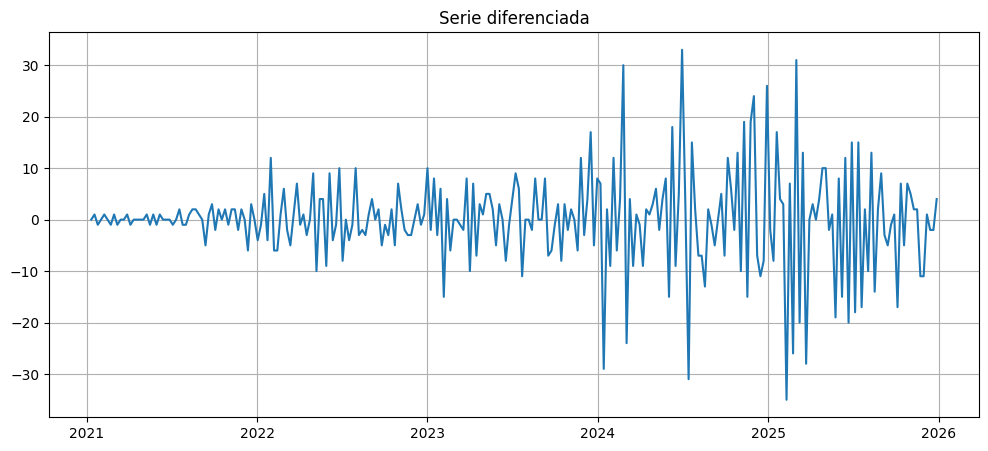

In [53]:
datos_originales_diferenciados = datos_procesados['casos_dengue'].diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(datos_originales_diferenciados)

plt.title('Serie diferenciada')
plt.grid(True)
plt.savefig(ubicacion_imagenes_janis + r'\2.serie_casos_originales_diferenciada.png', dpi=300)
plt.show()


## Diferenciación de la serie a datos procesados

In [43]:
datos_procesados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc',
       'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
       'soi_yj', 'sst_yj'],
      dtype='object')

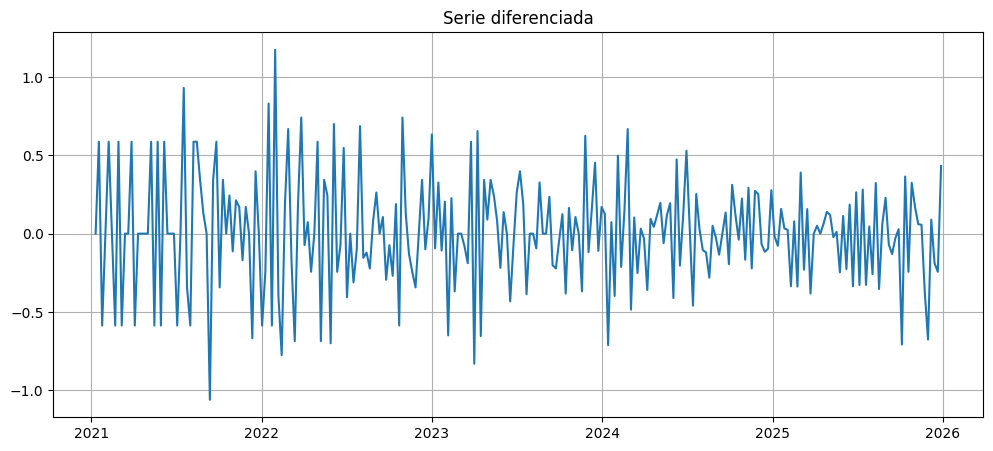

In [51]:
datos_procesados_diferenciados = datos_procesados['casos_ln'].diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(datos_procesados_diferenciados)

plt.title('Serie diferenciada')
plt.grid(True)
plt.savefig(ubicacion_imagenes_janis + r'\2.serie_casos_procesados_diferenciada.png', dpi=300)
plt.show()

## Se repite la prueba

### Datos originales diferenciados

In [46]:
from statsmodels.tsa.stattools import adfuller

# --- Aplicar ADF ---
resultado = adfuller(datos_originales_diferenciados)

# --- Mostrar resultados ---
print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])
print("Número de rezagos:", resultado[2])
print("Número de observaciones:", resultado[3])
print("Valores críticos:")

for key, value in resultado[4].items():
    print(f"   {key}: {value}")

# --- Conclusión ---
if resultado[1] <= 0.05:
    print("\n✔ La serie es ESTACIONARIA (no necesita diferenciación).")
else:
    print("\n✘ La serie NO es estacionaria (sí necesita diferenciación).")

ADF Statistic: -24.881373009716736
p-value: 0.0
Número de rezagos: 0
Número de observaciones: 259
Valores críticos:
   1%: -3.4558530692911504
   5%: -2.872764881778665
   10%: -2.572751643088207

✔ La serie es ESTACIONARIA (no necesita diferenciación).


### Datos procesados diferenciados

In [47]:
from statsmodels.tsa.stattools import adfuller

# --- Aplicar ADF ---
resultado = adfuller(datos_procesados_diferenciados)

# --- Mostrar resultados ---
print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])
print("Número de rezagos:", resultado[2])
print("Número de observaciones:", resultado[3])
print("Valores críticos:")

for key, value in resultado[4].items():
    print(f"   {key}: {value}")

# --- Conclusión ---
if resultado[1] <= 0.05:
    print("\n✔ La serie es ESTACIONARIA (no necesita diferenciación).")
else:
    print("\n✘ La serie NO es estacionaria (sí necesita diferenciación).")

ADF Statistic: -5.691025258288251
p-value: 8.070758113610913e-07
Número de rezagos: 9
Número de observaciones: 250
Valores críticos:
   1%: -3.456780859712
   5%: -2.8731715065600003
   10%: -2.572968544

✔ La serie es ESTACIONARIA (no necesita diferenciación).



## la serie se considera **estacionaria después de una diferenciación**, por lo que:

$$
I (d) = 1
$$

en el modelo ARIMA.

---



# 7. Evaluación de estacionalidad

Para datos semanales de dengue suele existir estacionalidad anual:

$$
s = 52
$$

Se puede observar mediante **descomposición temporal**.

```python


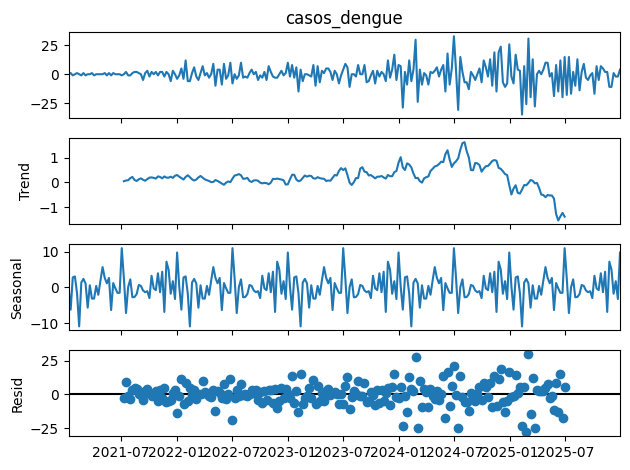

In [54]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomposicion = seasonal_decompose(datos_originales_diferenciados, model='additive', period=52)

descomposicion.plot()
plt.savefig(ubicacion_imagenes_janis + r'\3.descomposicion_serie_casos_originales_diferenciada.png', dpi=300)
plt.show()


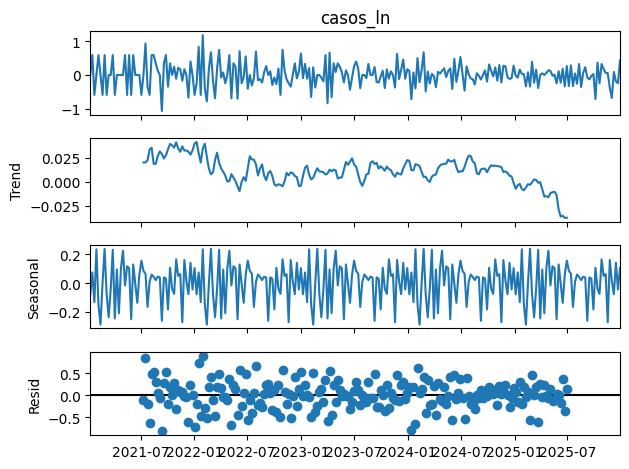

In [55]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomposicion = seasonal_decompose(datos_procesados_diferenciados, model='additive', period=52)

descomposicion.plot()
plt.savefig(ubicacion_imagenes_janis + r'\3.descomposicion_serie_casos_procesados_diferenciada.png', dpi=300)
plt.show()

# Interpretación del gráfico enterior  


El gráfico corresponde a una **descomposición temporal aditiva** de la serie semanal de casos de Dengue, obtenida mediante un procedimiento típico de análisis de series temporales en Python usando funciones de la biblioteca statsmodels. Esta descomposición separa la serie en cuatro componentes: **serie observada, tendencia, estacionalidad y residuales**. A continuación se interpreta particularmente el **componente estacional**, en el contexto de la evaluación de estacionalidad para la modelación con ARIMA o Seasonal ARIMA.

---

# 1. Presencia de un patrón estacional recurrente

El panel **Seasonal** muestra oscilaciones que se repiten alrededor de cero, con amplitudes aproximadas entre:

[
-12 \leq S_t \leq 12
]

Esto indica que existe un **componente periódico en la dinámica de los casos**, el cual se manifiesta como fluctuaciones sistemáticas alrededor de la tendencia.

### Interpretación epidemiológica

Este comportamiento sugiere que el número de casos de dengue presenta **variaciones recurrentes a lo largo del año**, lo cual es consistente con la epidemiología de la enfermedad, ya que la transmisión del virus depende de condiciones ambientales favorables para el mosquito *Aedes aegypti*, entre ellas:

* temperatura
* precipitación
* humedad relativa.

Estas variables influyen en:

* la reproducción del vector
* la disponibilidad de criaderos
* la supervivencia de larvas y adultos.

---

# 2. Magnitud moderada de la estacionalidad

Aunque el patrón estacional es visible, su magnitud es **menor que la tendencia** observada en el segundo panel.

Esto implica que:

[
Y_t = T_t + S_t + R_t
]

donde

* (T_t) (tendencia) explica una gran parte de la variación total,
* (S_t) (estacionalidad) introduce fluctuaciones periódicas,
* (R_t) representa variaciones aleatorias o ruido.

Por lo tanto, la **tendencia creciente en los casos de dengue parece ser el componente dominante de la serie**, mientras que la estacionalidad actúa como una modulación periódica.

---

# 3. Regularidad del ciclo estacional

El componente estacional presenta un patrón relativamente estable a lo largo del tiempo, lo que sugiere que la periodicidad del fenómeno es **consistente entre los diferentes años analizados**.

Dado que los datos están agregados por **semanas epidemiológicas**, la periodicidad esperada corresponde aproximadamente a:

[
s = 52
]

semanas por ciclo anual.

Este resultado es consistente con los ciclos epidemiológicos del dengue observados en regiones tropicales como Antioquia y particularmente en municipios del Bajo Cauca como Caucasia.

---

# 4. Variabilidad residual

El componente **Resid** muestra dispersión alrededor de cero, lo que indica que, después de eliminar tendencia y estacionalidad, la serie presenta fluctuaciones aleatorias.

Sin embargo, se observan algunos puntos extremos que podrían corresponder a:

* brotes epidémicos locales
* retrasos en el reporte de casos
* variabilidad inherente al proceso epidemiológico.

Estos valores atípicos deben considerarse durante la calibración del modelo.

---

# 5. Implicaciones para la modelación

El análisis sugiere que la serie presenta:

* tendencia creciente,
* estacionalidad anual moderada,
* ruido aleatorio alrededor del patrón estructural.

Por lo tanto, para el modelamiento predictivo en el sistema de alertas tempranas, es recomendable evaluar modelos de la forma:

[
SARIMA(p,d,q)(P,D,Q)_{52}
]

donde:

* (s = 52) representa el ciclo estacional anual en semanas epidemiológicas.

Este tipo de modelo permite capturar simultáneamente:

* la dinámica autoregresiva de la serie,
* los efectos de diferenciación necesarios para lograr estacionariedad,
* y los patrones periódicos asociados al comportamiento climático del vector.

---

## **Conclusión**

La descomposición temporal muestra que la serie de casos de dengue presenta **un componente estacional recurrente de carácter anual**, coherente con la dinámica climática de regiones tropicales. Aunque la tendencia creciente domina la estructura de la serie, la estacionalidad introduce fluctuaciones sistemáticas que deben incorporarse explícitamente en el modelo predictivo para mejorar la capacidad de anticipación dentro del sistema de alertas tempranas.

---



# 8. ACF y PACF

Una vez estacionaria la serie, se analizan:

* autocorrelación
* autocorrelación parcial

para determinar parámetros del modelo.



# PACF y ACF de la serie de datos originales

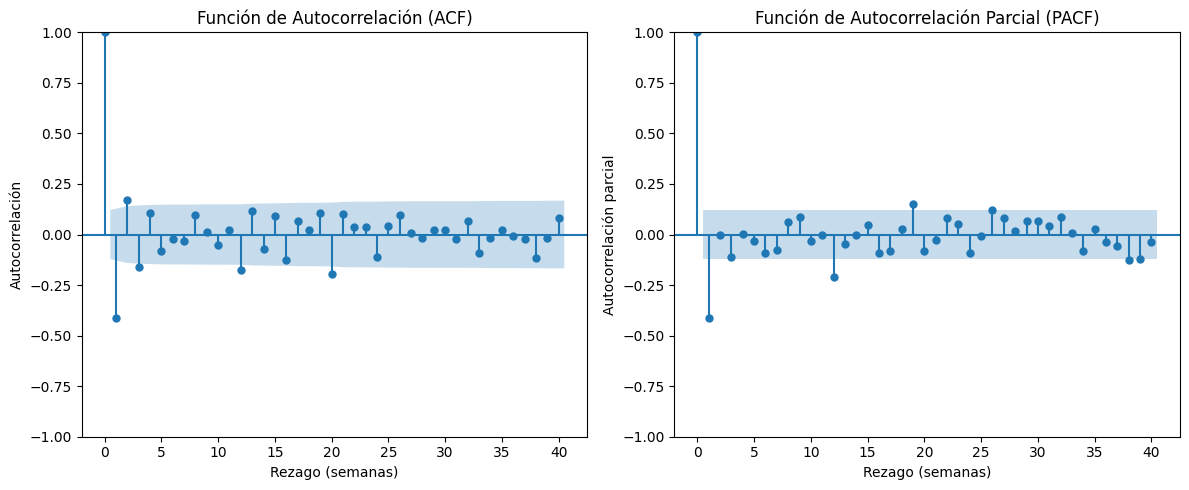

In [57]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Crear figura con dos subgráficos horizontales
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -------- ACF --------
plot_acf(datos_originales_diferenciados, lags=40, ax=axes[0])

axes[0].set_title('Función de Autocorrelación (ACF)')
axes[0].set_xlabel('Rezago (semanas)')
axes[0].set_ylabel('Autocorrelación')

# -------- PACF --------
plot_pacf(datos_originales_diferenciados, lags=40, ax=axes[1])

axes[1].set_title('Función de Autocorrelación Parcial (PACF)')
axes[1].set_xlabel('Rezago (semanas)')
axes[1].set_ylabel('Autocorrelación parcial')

plt.tight_layout()

plt.savefig(ubicacion_imagenes_janis + r'\4.acf_pacf_casos_originales_diferenciada.png', dpi=300)

plt.show()

# PACF y ACF de la serie de datos procesados

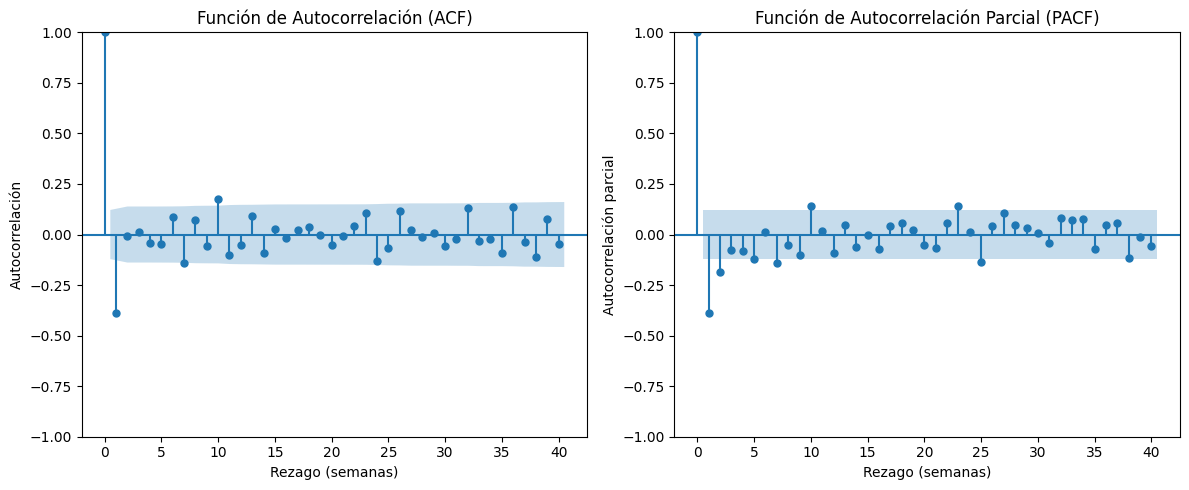

In [58]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Crear figura con dos subgráficos horizontales
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -------- ACF --------
plot_acf(datos_procesados_diferenciados, lags=40, ax=axes[0])

axes[0].set_title('Función de Autocorrelación (ACF)')
axes[0].set_xlabel('Rezago (semanas)')
axes[0].set_ylabel('Autocorrelación')

# -------- PACF --------
plot_pacf(datos_procesados_diferenciados, lags=40, ax=axes[1])

axes[1].set_title('Función de Autocorrelación Parcial (PACF)')
axes[1].set_xlabel('Rezago (semanas)')
axes[1].set_ylabel('Autocorrelación parcial')

plt.tight_layout()

plt.savefig(ubicacion_imagenes_janis + r'\4.acf_pacf_casos_procesados_diferenciada.png', dpi=300)

plt.show()


En el proceso de identificación de un modelo SARIMAX para la predicción de casos de Dengue, los gráficos de **ACF (Autocorrelation Function)** y **PACF (Partial Autocorrelation Function)** permiten inferir los parámetros autoregresivos y de media móvil del modelo.

Recordemos que un modelo SARIMAX tiene la estructura:

$$
SARIMAX(p,d,q)(P,D,Q)_s
$$

donde:

* $p$: orden autoregresivo
* (d): diferenciación
* (q): orden de media móvil
* $P$: componente autoregresivo estacional
* (D): diferenciación estacional
* (Q): componente de media móvil estacional
* $s$: periodo estacional (para datos semanales de dengue normalmente $s=52$).

---



# 1. Interpretación del gráfico ACF

En el gráfico de **ACF** se observa lo siguiente:

### a) Rezago 0

Como es esperado, la autocorrelación en:

$$
lag = 0
$$

es igual a **1**, ya que toda serie está perfectamente correlacionada consigo misma.

---



### b) Rezago 1–2

Se observa una **autocorrelación negativa significativa alrededor del rezago 3**, que cae fuera del intervalo de confianza.

Esto sugiere la presencia de un **componente de media móvil (MA)** en la serie.

Cuando en el ACF:

* hay un **pico significativo en los primeros rezagos**
* y luego las correlaciones se atenúan rápidamente

esto suele indicar un proceso:

$$
MA(q)
$$

con **q pequeño**, generalmente:

$$
q = 1 \quad \text{o} \quad q = 2
$$

---

### c) Resto de los rezagos

Después del rezago 3, la mayoría de los valores permanecen dentro del intervalo de confianza.

Esto sugiere que:

* no existe una memoria larga significativa
* la estructura temporal es relativamente corta.

---
